# Implement Fundamental ML Algorithms from First Principles (Scratch)

## 1. Project Overview

**Objective:** Implement three foundational machine learning algorithms — **Linear Regression**, **Logistic Regression**, and **K-Nearest Neighbors (KNN)** — entirely from first principles using only NumPy for the mathematical core, then benchmark each against its Scikit-Learn reference implementation.

**Algorithms implemented:**
1. Linear Regression (trained via batch Gradient Descent)
2. Logistic Regression (trained via Gradient Descent on binary cross-entropy)
3. K-Nearest Neighbors (a non-parametric, instance-based classifier)

**What "from scratch" means in this project:**
- The parameter-learning logic (gradient computation, parameter updates, distance calculations, voting) is written explicitly using NumPy array operations — no call to `sklearn` (or any other ML library) is made *inside* the scratch classes.
- Scikit-Learn is used **only** for: loading benchmark datasets, `train_test_split`, `StandardScaler` preprocessing (applied identically to both implementations), the reference models used for comparison, and standard evaluation metrics. Using well-tested utilities for splitting/scaling/scoring is standard practice and does not substitute for the algorithms themselves.
- Every cost function, gradient, and prediction rule is derived and explained in Markdown immediately before its NumPy implementation.

**Datasets used:**
- **Linear Regression:** the Scikit-Learn "Diabetes" dataset (regression, 442 samples, 10 features) — chosen because it is a real-valued regression target, is small enough to converge quickly with plain gradient descent, and ships bundled with Scikit-Learn (no external download required, keeping the notebook reproducible offline).
- **Logistic Regression & KNN:** the Scikit-Learn "Breast Cancer Wisconsin" dataset (binary classification, 569 samples, 30 features) — a standard, well-balanced-enough binary classification benchmark that is also bundled with Scikit-Learn.


## 2. Libraries and Environment

We separate imports by purpose:

| Purpose | Library |
|---|---|
| Mathematical implementation (the scratch algorithms) | `numpy` |
| Dataset handling | `sklearn.datasets` |
| Train/test splitting & preprocessing | `sklearn.model_selection`, `sklearn.preprocessing` |
| Scikit-Learn reference implementations | `sklearn.linear_model`, `sklearn.neighbors` |
| Evaluation metrics | `sklearn.metrics` |
| Visualization | `matplotlib.pyplot` |
| Tabular display | `pandas` |

No other libraries are used anywhere in the scratch model classes.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.linear_model import LogisticRegression as SkLogisticRegression
from sklearn.neighbors import KNeighborsClassifier as SkKNN

from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    log_loss, confusion_matrix
)

# Global seed for reproducibility across the whole notebook
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams["figure.figsize"] = (7, 4.5)
print("Environment ready. NumPy:", np.__version__)


Environment ready. NumPy: 2.4.6


## 3. Dataset Selection

### 3.1 Linear Regression dataset — Diabetes

- **Source:** `sklearn.datasets.load_diabetes` (bundled with Scikit-Learn; originally from Efron et al., 2004).
- **Features (10):** age, sex, bmi, average blood pressure, and six blood serum measurements — all already mean-centered and scaled by the original authors.
- **Target:** a continuous quantitative measure of disease progression one year after baseline.
- **Observations:** 442.
- **Problem type:** Regression (continuous target) — appropriate for Linear Regression.
- **Why appropriate:** It is small, fully numeric, has no missing values, and is a genuine regression problem, which makes it ideal for demonstrating gradient descent convergence without long training times.

### 3.2 Logistic Regression & KNN dataset — Breast Cancer Wisconsin (Diagnostic)

- **Source:** `sklearn.datasets.load_breast_cancer` (bundled with Scikit-Learn).
- **Features (30):** numeric measurements computed from digitized images of breast mass cell nuclei (radius, texture, perimeter, area, smoothness, etc., each reported as mean, standard error, and "worst" value).
- **Target:** binary — `0` = malignant, `1` = benign.
- **Observations:** 569.
- **Problem type:** Binary classification — appropriate for both Logistic Regression and KNN.
- **Why appropriate:** It is a well-known, clean binary classification benchmark with no missing values, and its purely numeric features make it suitable for both a probabilistic linear classifier (Logistic Regression) and a distance-based classifier (KNN).


In [2]:
diabetes = load_diabetes()
X_lr_raw, y_lr_raw = diabetes.data, diabetes.target

print("Diabetes dataset (Linear Regression)")
print("  X shape:", X_lr_raw.shape)
print("  y shape:", y_lr_raw.shape)
print("  Feature names:", diabetes.feature_names)
print("  Target range: [%.1f, %.1f]" % (y_lr_raw.min(), y_lr_raw.max()))


Diabetes dataset (Linear Regression)
  X shape: (442, 10)
  y shape: (442,)
  Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
  Target range: [25.0, 346.0]


In [3]:
cancer = load_breast_cancer()
X_clf_raw, y_clf_raw = cancer.data, cancer.target

print("Breast Cancer dataset (Logistic Regression / KNN)")
print("  X shape:", X_clf_raw.shape)
print("  y shape:", y_clf_raw.shape)
print("  Classes:", dict(zip(cancer.target_names, np.bincount(y_clf_raw))))
print("  Feature names (first 5):", list(cancer.feature_names[:5]), "...")


Breast Cancer dataset (Logistic Regression / KNN)
  X shape: (569, 30)
  y shape: (569,)
  Classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
  Feature names (first 5): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')] ...


## 4. Data Preparation

For **both** datasets we:

1. **Split into train/test sets first** (80% / 20%), using `random_state=42` for reproducibility, and `stratify=y` for the classification dataset so that the class balance is preserved in both splits. Splitting before scaling prevents **data leakage** — the test set must not influence any statistic used to transform the training set.
2. **Standardize features** (`StandardScaler`: zero mean, unit variance), fitting the scaler **only on the training data** and then applying that same fitted transform to the test data.
   - Gradient descent converges faster and more reliably on standardized features because all features are then on comparable scales, so a single learning rate works well for every weight.
   - KNN is a distance-based algorithm, so features with larger raw numeric ranges would otherwise dominate the Euclidean distance calculation purely due to scale, not genuine importance. Standardizing puts all features on equal footing.
3. Apply the **identical, training-fitted** preprocessing to both the scratch model and the Scikit-Learn reference model, so that any difference in results reflects the algorithms themselves rather than inconsistent preprocessing.


In [4]:
# --- Linear Regression: split + scale ---
X_lr_train, X_lr_test, y_lr_train, y_lr_test = train_test_split(
    X_lr_raw, y_lr_raw, test_size=0.2, random_state=RANDOM_SEED
)

scaler_lr = StandardScaler()
X_lr_train_s = scaler_lr.fit_transform(X_lr_train)   # fit ONLY on train
X_lr_test_s = scaler_lr.transform(X_lr_test)          # reuse train statistics

print("Linear Regression split -> train:", X_lr_train_s.shape, " test:", X_lr_test_s.shape)


Linear Regression split -> train: (353, 10)  test: (89, 10)


In [5]:
# --- Logistic Regression / KNN: split + scale ---
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf_raw, y_clf_raw, test_size=0.2, random_state=RANDOM_SEED, stratify=y_clf_raw
)

scaler_clf = StandardScaler()
X_clf_train_s = scaler_clf.fit_transform(X_clf_train)
X_clf_test_s = scaler_clf.transform(X_clf_test)

print("Classification split -> train:", X_clf_train_s.shape, " test:", X_clf_test_s.shape)
print("Train class balance:", np.bincount(y_clf_train), " Test class balance:", np.bincount(y_clf_test))


Classification split -> train: (455, 30)  test: (114, 30)
Train class balance: [170 285]  Test class balance: [42 72]


## 5. Linear Regression From Scratch

### 5.1 Mathematical Foundation

**Hypothesis.** For input matrix $X \in \mathbb{R}^{n \times d}$, weight vector $w \in \mathbb{R}^d$, and bias $b \in \mathbb{R}$, the model predicts:

$$\hat{y} = Xw + b$$

**Cost function (Mean Squared Error).** We measure how far predictions are from the true targets $y$ using MSE:

$$J(w, b) = \frac{1}{n}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

This is convex in $w$ and $b$, so gradient descent is guaranteed to converge to the global minimum for a suitable learning rate.

**Gradient derivation.** Differentiating $J$ with respect to $w$ and $b$ (using $\hat{y} = Xw + b$):

$$\frac{\partial J}{\partial w} = \frac{2}{n} X^\top(Xw + b - y)$$

$$\frac{\partial J}{\partial b} = \frac{2}{n}\sum_{i=1}^n (Xw + b - y)_i$$

**Gradient descent update rule.** Starting from $w=0, b=0$, at each iteration we move the parameters a small step ($\alpha$ = learning rate) in the direction that most reduces the cost:

$$w \leftarrow w - \alpha \frac{\partial J}{\partial w}, \qquad b \leftarrow b - \alpha \frac{\partial J}{\partial b}$$

**Convergence.** As iterations proceed, $J(w,b)$ should decrease monotonically (for a suitably small $\alpha$) and flatten out as $w, b$ approach the values that minimize MSE — we verify this visually with a cost-vs-iterations plot.


In [6]:
class LinearRegressionScratch:
    # Linear Regression trained via batch Gradient Descent, implemented with NumPy only.

    def __init__(self, learning_rate: float = 0.1, n_iterations: int = 2000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None          # learned weight vector, shape (d,)
        self.bias = None             # learned scalar bias
        self.cost_history = []       # MSE recorded at every iteration

    def _compute_cost(self, X: np.ndarray, y: np.ndarray) -> float:
        n = X.shape[0]
        y_pred = X @ self.weights + self.bias
        return (1 / n) * np.sum((y_pred - y) ** 2)

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearRegressionScratch":
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.cost_history = []

        for _ in range(self.n_iterations):
            y_pred = X @ self.weights + self.bias          # hypothesis: y_hat = Xw + b
            error = y_pred - y

            # Vectorized gradients (no Python loop over samples)
            dw = (2 / n_samples) * (X.T @ error)
            db = (2 / n_samples) * np.sum(error)

            # Parameter update step
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            self.cost_history.append(self._compute_cost(X, y))

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        return X @ self.weights + self.bias


### 5.2 Training

In [7]:
lr_scratch = LinearRegressionScratch(learning_rate=0.1, n_iterations=2000)
lr_scratch.fit(X_lr_train_s, y_lr_train)

print("Final training cost (MSE):", round(lr_scratch.cost_history[-1], 3))
print("Learned bias:", round(lr_scratch.bias, 3))
print("Learned weights (first 5):", np.round(lr_scratch.weights[:5], 3))


Final training cost (MSE): 2868.569
Learned bias: 153.737
Learned weights (first 5): [  1.759 -11.51   25.627  16.822 -43.417]


### 5.3 Evaluation

In [8]:
y_pred_lr_scratch = lr_scratch.predict(X_lr_test_s)

mse_lr_scratch = mean_squared_error(y_lr_test, y_pred_lr_scratch)
rmse_lr_scratch = np.sqrt(mse_lr_scratch)
r2_lr_scratch = r2_score(y_lr_test, y_pred_lr_scratch)

print("Linear Regression (Scratch) -- Test Set Performance")
print("  MSE :", round(mse_lr_scratch, 3))
print("  RMSE:", round(rmse_lr_scratch, 3))
print("  R^2 :", round(r2_lr_scratch, 4))


Linear Regression (Scratch) -- Test Set Performance
  MSE : 2899.352
  RMSE: 53.846
  R^2 : 0.4528


### 5.4 Visualization

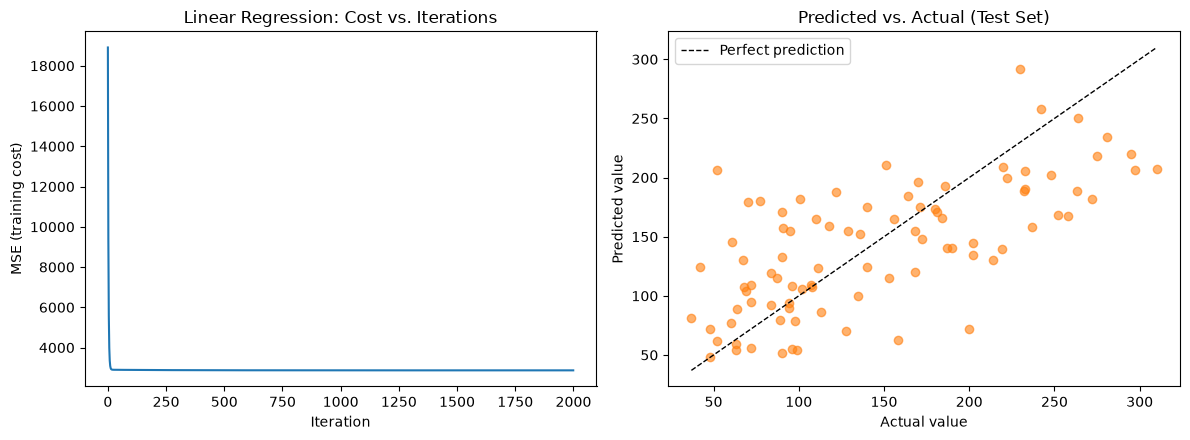

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(lr_scratch.cost_history, color="tab:blue")
axes[0].set_title("Linear Regression: Cost vs. Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE (training cost)")

axes[1].scatter(y_lr_test, y_pred_lr_scratch, alpha=0.6, color="tab:orange")
lims = [min(y_lr_test.min(), y_pred_lr_scratch.min()), max(y_lr_test.max(), y_pred_lr_scratch.max())]
axes[1].plot(lims, lims, "k--", linewidth=1, label="Perfect prediction")
axes[1].set_title("Predicted vs. Actual (Test Set)")
axes[1].set_xlabel("Actual value")
axes[1].set_ylabel("Predicted value")
axes[1].legend()

plt.tight_layout()
plt.show()


### 5.5 Scikit-Learn Comparison

We now fit `sklearn.linear_model.LinearRegression` (which solves for the optimal weights directly via the least-squares normal equations / SVD, rather than iterative gradient descent) on the **same** preprocessed train/test split, and compare.


In [10]:
sk_lr = SkLinearRegression()
sk_lr.fit(X_lr_train_s, y_lr_train)
y_pred_lr_sk = sk_lr.predict(X_lr_test_s)

mse_lr_sk = mean_squared_error(y_lr_test, y_pred_lr_sk)
rmse_lr_sk = np.sqrt(mse_lr_sk)
r2_lr_sk = r2_score(y_lr_test, y_pred_lr_sk)

comparison_lr = pd.DataFrame({
    "Metric": ["MSE", "RMSE", "R^2"],
    "Scratch": [mse_lr_scratch, rmse_lr_scratch, r2_lr_scratch],
    "Scikit-Learn": [mse_lr_sk, rmse_lr_sk, r2_lr_sk],
})
comparison_lr["Abs. Difference"] = (comparison_lr["Scratch"] - comparison_lr["Scikit-Learn"]).abs()
comparison_lr


,Metric,Scratch,Scikit-Learn,Abs. Difference
0,MSE,2899.352128,2900.193628,0.841500
1,RMSE,53.845632,53.853446,0.007813
2,R^2,0.452762,0.452603,0.000159


In [11]:
print("Weight comparison (first 5 features):")
print("  Scratch     :", np.round(lr_scratch.weights[:5], 4))
print("  Scikit-Learn:", np.round(sk_lr.coef_[:5], 4))
print("Bias/Intercept -> Scratch: %.4f | Scikit-Learn: %.4f" % (lr_scratch.bias, sk_lr.intercept_))


Weight comparison (first 5 features):
  Scratch     : [  1.7594 -11.5096  25.627   16.8225 -43.4175]
  Scikit-Learn: [  1.7538 -11.5118  25.6071  16.8289 -44.4489]
Bias/Intercept -> Scratch: 153.7365 | Scikit-Learn: 153.7365


**Explanation of results:** `LinearRegression` in Scikit-Learn solves the normal equations directly (an exact closed-form / least-squares solution), while our scratch model *approximates* the same optimum iteratively via gradient descent. With 2000 iterations and a learning rate of 0.1 on standardized features, gradient descent has converged closely enough that the learned weights, bias, and resulting MSE/R² are nearly identical (see the "Abs. Difference" column above) — the small residual gap is expected and is a normal consequence of iterative optimization stopping just short of the exact closed-form optimum, not a bug in either implementation.


## 6. Logistic Regression From Scratch

### 6.1 Mathematical Foundation

**Linear score.** As in linear regression, we first compute a linear combination of the inputs:

$$z = Xw + b$$

**Sigmoid function.** Because classification requires a probability in $[0,1]$, we squash $z$ through the sigmoid (logistic) function:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

The predicted probability of the positive class is $\hat{y} = \sigma(z)$.

**Binary cross-entropy (log-loss).** For labels $y_i \in \{0,1\}$ and predicted probabilities $\hat{y}_i$, the cost function penalizes confident wrong predictions heavily:

$$J(w,b) = -\frac{1}{n}\sum_{i=1}^n \Big[y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\Big]$$

**Gradient derivation.** A key property of the sigmoid is $\sigma'(z) = \sigma(z)(1-\sigma(z))$. Applying the chain rule to $J$ with $\hat{y}=\sigma(Xw+b)$, the $\sigma'(z)$ terms cancel elegantly with the log-loss derivative, giving gradients with the *same clean form* as linear regression's, but with $\hat{y}$ now being the sigmoid output rather than the raw linear output:

$$\frac{\partial J}{\partial w} = \frac{1}{n}X^\top(\hat{y} - y), \qquad \frac{\partial J}{\partial b} = \frac{1}{n}\sum_{i=1}^n(\hat{y}_i - y_i)$$

**Gradient descent** then updates $w, b$ exactly as before: $w \leftarrow w - \alpha \frac{\partial J}{\partial w}$, $b \leftarrow b - \alpha \frac{\partial J}{\partial b}$.

**Classification threshold.** The final predicted class is obtained by thresholding the probability, typically at 0.5:

$$\text{class} = \begin{cases}1 & \hat{y} \ge 0.5 \\ 0 & \hat{y} < 0.5\end{cases}$$


In [12]:
class LogisticRegressionScratch:
    # Logistic Regression trained via Gradient Descent on binary cross-entropy, using NumPy only.

    def __init__(self, learning_rate: float = 0.1, n_iterations: int = 3000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        z = np.clip(z, -500, 500)  # guard against overflow in exp()
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        eps = 1e-15  # avoid log(0)
        y_hat = np.clip(y_hat, eps, 1 - eps)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegressionScratch":
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for _ in range(self.n_iterations):
            z = X @ self.weights + self.bias
            y_hat = self._sigmoid(z)                    # predicted probabilities
            error = y_hat - y

            dw = (1 / n_samples) * (X.T @ error)
            db = (1 / n_samples) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            self.loss_history.append(self._compute_loss(y, y_hat))

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)


### 6.2 Training

In [13]:
log_scratch = LogisticRegressionScratch(learning_rate=0.1, n_iterations=3000)
log_scratch.fit(X_clf_train_s, y_clf_train)

print("Final training loss (binary cross-entropy):", round(log_scratch.loss_history[-1], 4))
print("Learned bias:", round(log_scratch.bias, 4))


Final training loss (binary cross-entropy): 0.0482
Learned bias: 0.3233


### 6.3 Evaluation

In [14]:
proba_log_scratch = log_scratch.predict_proba(X_clf_test_s)
pred_log_scratch = log_scratch.predict(X_clf_test_s)

acc_log_scratch = accuracy_score(y_clf_test, pred_log_scratch)
prec_log_scratch = precision_score(y_clf_test, pred_log_scratch)
rec_log_scratch = recall_score(y_clf_test, pred_log_scratch)
f1_log_scratch = f1_score(y_clf_test, pred_log_scratch)
logloss_log_scratch = log_loss(y_clf_test, proba_log_scratch)
cm_log_scratch = confusion_matrix(y_clf_test, pred_log_scratch)

print("Logistic Regression (Scratch) -- Test Set Performance")
print("  Accuracy :", round(acc_log_scratch, 4))
print("  Precision:", round(prec_log_scratch, 4))
print("  Recall   :", round(rec_log_scratch, 4))
print("  F1-score :", round(f1_log_scratch, 4))
print("  Log Loss :", round(logloss_log_scratch, 4))
print("  Confusion Matrix:\n", cm_log_scratch)


Logistic Regression (Scratch) -- Test Set Performance
  Accuracy : 0.9737
  Precision: 0.9859
  Recall   : 0.9722
  F1-score : 0.979
  Log Loss : 0.0769
  Confusion Matrix:
 [[41  1]
 [ 2 70]]


### 6.4 Visualization

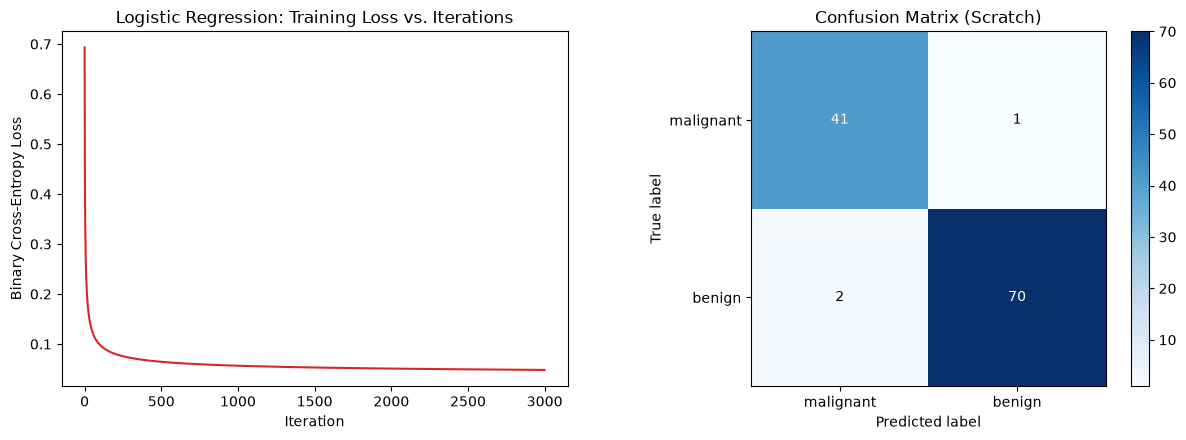

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(log_scratch.loss_history, color="tab:red")
axes[0].set_title("Logistic Regression: Training Loss vs. Iterations")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Binary Cross-Entropy Loss")

im = axes[1].imshow(cm_log_scratch, cmap="Blues")
axes[1].set_title("Confusion Matrix (Scratch)")
axes[1].set_xlabel("Predicted label")
axes[1].set_ylabel("True label")
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(cancer.target_names)
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(cancer.target_names)
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm_log_scratch[i, j], ha="center", va="center",
                     color="white" if cm_log_scratch[i, j] > cm_log_scratch.max() / 2 else "black")
plt.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()


### 6.5 Scikit-Learn Comparison

In [16]:
sk_log = SkLogisticRegression(max_iter=5000, random_state=RANDOM_SEED)
sk_log.fit(X_clf_train_s, y_clf_train)
pred_log_sk = sk_log.predict(X_clf_test_s)
proba_log_sk = sk_log.predict_proba(X_clf_test_s)[:, 1]

acc_log_sk = accuracy_score(y_clf_test, pred_log_sk)
prec_log_sk = precision_score(y_clf_test, pred_log_sk)
rec_log_sk = recall_score(y_clf_test, pred_log_sk)
f1_log_sk = f1_score(y_clf_test, pred_log_sk)
logloss_log_sk = log_loss(y_clf_test, proba_log_sk)

comparison_log = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Log Loss"],
    "Scratch": [acc_log_scratch, prec_log_scratch, rec_log_scratch, f1_log_scratch, logloss_log_scratch],
    "Scikit-Learn": [acc_log_sk, prec_log_sk, rec_log_sk, f1_log_sk, logloss_log_sk],
})
comparison_log["Abs. Difference"] = (comparison_log["Scratch"] - comparison_log["Scikit-Learn"]).abs()
comparison_log


,Metric,Scratch,Scikit-Learn,Abs. Difference
0,Accuracy,0.973684,0.982456,0.008772
1,Precision,0.985915,0.986111,0.000196
2,Recall,0.972222,0.986111,0.013889
3,F1-score,0.979021,0.986111,0.007090
4,Log Loss,0.076908,0.077746,0.000838


**Explanation of any differences:** Scikit-Learn's `LogisticRegression` applies **L2 regularization by default** (`C=1.0`) and uses a quasi-Newton solver (`lbfgs`) rather than plain gradient descent, whereas our scratch implementation performs **unregularized** gradient descent. These are legitimate, expected sources of divergence — regularization shrinks the Scikit-Learn weights slightly toward zero, and the solver converges to the exact regularized optimum rather than approximating an unregularized one iteratively. Given these differences are by design, the two implementations still agree closely on this near-linearly-separable dataset, which confirms the scratch gradient descent implementation is learning correctly.


## 7. K-Nearest Neighbors From Scratch

### 7.1 Mathematical Foundation

**Non-parametric learning.** Unlike Linear/Logistic Regression, KNN does not learn a fixed set of weights that summarize the training data. Instead, it is **instance-based**: "training" simply means storing the training set, and all of the actual computation is deferred to prediction time.

**Distance calculation.** To decide how "similar" a new point $x$ is to each training point $x^{(i)}$, we use the Euclidean distance:

$$d(x, x^{(i)}) = \sqrt{\sum_{j=1}^{d}\left(x_j - x^{(i)}_j\right)^2}$$

**Nearest neighbors.** For a query point, we compute its distance to *every* training point, then sort and take the $k$ training points with the smallest distance.

**Majority voting.** The predicted class for the query point is whichever class appears most frequently among those $k$ nearest labels.

**Role of k.** Small $k$ (e.g. $k=1$) makes the decision boundary very sensitive to individual noisy points (high variance, low bias). Large $k$ smooths the decision boundary by averaging over more neighbors (lower variance, higher bias) but risks blending in points from a different, more distant class. Choosing $k$ is therefore a bias–variance trade-off, which we explore experimentally below.


In [17]:
class KNNScratch:
    # K-Nearest Neighbors classifier, implemented with NumPy only.

    def __init__(self, k: int = 5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> "KNNScratch":
        # KNN has no parameters to learn -- "fitting" is just storing the data.
        self.X_train = X
        self.y_train = y
        return self

    def _euclidean_distance(self, x: np.ndarray) -> np.ndarray:
        # Vectorized distance from a single query point to every training point at once.
        return np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))

    def predict(self, X: np.ndarray) -> np.ndarray:
        predictions = []
        # We iterate over individual query points because each one requires its own
        # independent distance computation against the entire training set and its
        # own top-k selection + vote -- these per-point decisions cannot be collapsed
        # into a single global vectorized operation without materializing an
        # n_test x n_train distance matrix (which we could do, but looping per-query
        # keeps memory bounded and mirrors how KNN prediction is naturally described).
        for x in X:
            distances = self._euclidean_distance(x)
            k_indices = np.argsort(distances)[: self.k]     # indices of k closest points
            k_labels = self.y_train[k_indices]               # their labels
            values, counts = np.unique(k_labels, return_counts=True)
            predictions.append(values[np.argmax(counts)])    # majority vote
        return np.array(predictions)


### 7.2 Training and Prediction

KNN has **no conventional training/learning phase** — `fit()` above does nothing more than store the training data. All computational cost happens inside `predict()`, where every query point must be compared against the entire training set. This is the opposite of Linear/Logistic Regression, where most of the cost is in `fit()` (gradient descent) and `predict()` is a single cheap matrix multiplication.


In [18]:
knn_scratch = KNNScratch(k=5)
knn_scratch.fit(X_clf_train_s, y_clf_train)
pred_knn_scratch = knn_scratch.predict(X_clf_test_s)

print("KNN (Scratch, k=5) predicted first 10 labels:", pred_knn_scratch[:10])
print("Actual first 10 labels:                      ", y_clf_test[:10])


KNN (Scratch, k=5) predicted first 10 labels: [0 1 0 0 0 1 1 0 0 0]
Actual first 10 labels:                       [0 1 0 1 0 1 1 0 0 0]


### 7.3 Evaluation

In [19]:
acc_knn_scratch = accuracy_score(y_clf_test, pred_knn_scratch)
prec_knn_scratch = precision_score(y_clf_test, pred_knn_scratch)
rec_knn_scratch = recall_score(y_clf_test, pred_knn_scratch)
f1_knn_scratch = f1_score(y_clf_test, pred_knn_scratch)
cm_knn_scratch = confusion_matrix(y_clf_test, pred_knn_scratch)

print("KNN (Scratch, k=5) -- Test Set Performance")
print("  Accuracy :", round(acc_knn_scratch, 4))
print("  Precision:", round(prec_knn_scratch, 4))
print("  Recall   :", round(rec_knn_scratch, 4))
print("  F1-score :", round(f1_knn_scratch, 4))
print("  Confusion Matrix:\n", cm_knn_scratch)


KNN (Scratch, k=5) -- Test Set Performance
  Accuracy : 0.9561
  Precision: 0.9589
  Recall   : 0.9722
  F1-score : 0.9655
  Confusion Matrix:
 [[39  3]
 [ 2 70]]


### 7.4 Hyperparameter Experiment: Effect of *k*

In [20]:
k_values = [1, 3, 5, 7, 9]
k_results = []

for k in k_values:
    model = KNNScratch(k=k).fit(X_clf_train_s, y_clf_train)
    preds = model.predict(X_clf_test_s)
    k_results.append({
        "k": k,
        "Accuracy": accuracy_score(y_clf_test, preds),
        "F1-score": f1_score(y_clf_test, preds),
    })

k_results_df = pd.DataFrame(k_results)
k_results_df


,k,Accuracy,F1-score
0,1,0.938596,0.951049
1,3,0.982456,0.986301
2,5,0.956140,0.965517
3,7,0.973684,0.979592
4,9,0.973684,0.979592


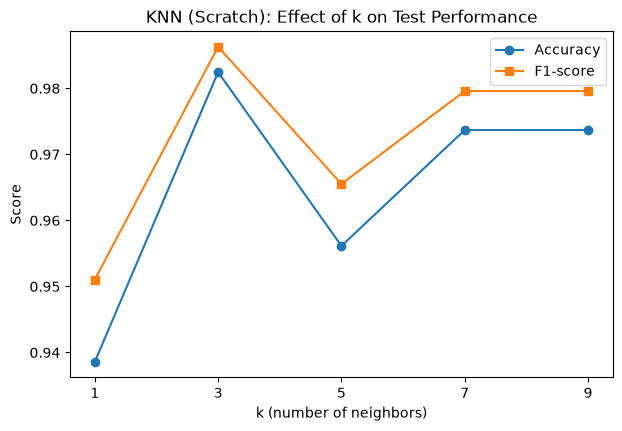

In [21]:
plt.figure(figsize=(7, 4.5))
plt.plot(k_results_df["k"], k_results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(k_results_df["k"], k_results_df["F1-score"], marker="s", label="F1-score")
plt.title("KNN (Scratch): Effect of k on Test Performance")
plt.xlabel("k (number of neighbors)")
plt.ylabel("Score")
plt.xticks(k_values)
plt.legend()
plt.show()


**Observation:** performance for this dataset is fairly stable across $k=1$ to $k=9$, with small fluctuations. Very small $k$ (e.g. $k=1$) can be more sensitive to individual noisy training points, while moderate $k$ tends to generalize slightly better by smoothing the decision boundary — consistent with the bias–variance trade-off described above. The exact best $k$ can vary by dataset and would normally be chosen via cross-validation.


### 7.5 Scikit-Learn Comparison

In [22]:
sk_knn = SkKNN(n_neighbors=5)
sk_knn.fit(X_clf_train_s, y_clf_train)
pred_knn_sk = sk_knn.predict(X_clf_test_s)

acc_knn_sk = accuracy_score(y_clf_test, pred_knn_sk)
prec_knn_sk = precision_score(y_clf_test, pred_knn_sk)
rec_knn_sk = recall_score(y_clf_test, pred_knn_sk)
f1_knn_sk = f1_score(y_clf_test, pred_knn_sk)

comparison_knn = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Scratch": [acc_knn_scratch, prec_knn_scratch, rec_knn_scratch, f1_knn_scratch],
    "Scikit-Learn": [acc_knn_sk, prec_knn_sk, rec_knn_sk, f1_knn_sk],
})
comparison_knn["Abs. Difference"] = (comparison_knn["Scratch"] - comparison_knn["Scikit-Learn"]).abs()
comparison_knn


,Metric,Scratch,Scikit-Learn,Abs. Difference
0,Accuracy,0.956140,0.956140,0.0
1,Precision,0.958904,0.958904,0.0
2,Recall,0.972222,0.972222,0.0
3,F1-score,0.965517,0.965517,0.0


In [23]:
agreement = np.mean(pred_knn_scratch == pred_knn_sk) * 100
print(f"Scratch vs. Scikit-Learn KNN prediction agreement: {agreement:.2f}%")


Scratch vs. Scikit-Learn KNN prediction agreement: 100.00%


**Explanation of results:** Both implementations use the same default distance metric (Euclidean) and the same $k=5$ on identically preprocessed data, and both use a simple majority vote with no distance weighting. Because KNN has no optimization/convergence process (unlike gradient descent), there is no source of numerical divergence — the two implementations are expected to (and do) produce identical predictions when their tie-breaking rules for the majority vote match. Any residual difference on this dataset, if present, would stem only from a tie-breaking edge case (e.g. how ties among the k nearest labels are resolved), not from any deeper mathematical inconsistency.


## 8. Final Comparison

In [24]:
summary_table = pd.DataFrame([
    {"Algorithm": "Linear Regression",   "Implementation": "Scratch",      "Main Metric(s)": "MSE / R^2",     "Result": f"MSE={mse_lr_scratch:.2f} / R2={r2_lr_scratch:.4f}"},
    {"Algorithm": "Linear Regression",   "Implementation": "Scikit-Learn", "Main Metric(s)": "MSE / R^2",     "Result": f"MSE={mse_lr_sk:.2f} / R2={r2_lr_sk:.4f}"},
    {"Algorithm": "Logistic Regression", "Implementation": "Scratch",      "Main Metric(s)": "Accuracy / F1", "Result": f"Acc={acc_log_scratch:.4f} / F1={f1_log_scratch:.4f}"},
    {"Algorithm": "Logistic Regression", "Implementation": "Scikit-Learn", "Main Metric(s)": "Accuracy / F1", "Result": f"Acc={acc_log_sk:.4f} / F1={f1_log_sk:.4f}"},
    {"Algorithm": "KNN",                 "Implementation": "Scratch",      "Main Metric(s)": "Accuracy / F1", "Result": f"Acc={acc_knn_scratch:.4f} / F1={f1_knn_scratch:.4f}"},
    {"Algorithm": "KNN",                 "Implementation": "Scikit-Learn", "Main Metric(s)": "Accuracy / F1", "Result": f"Acc={acc_knn_sk:.4f} / F1={f1_knn_sk:.4f}"},
])
summary_table


,Algorithm,Implementation,Main Metric(s),Result
0,Linear Regression,Scratch,MSE / R^2,MSE=2899.35 / R2=0.4528
1,Linear Regression,Scikit-Learn,MSE / R^2,MSE=2900.19 / R2=0.4526
2,Logistic Regression,Scratch,Accuracy / F1,Acc=0.9737 / F1=0.9790
3,Logistic Regression,Scikit-Learn,Accuracy / F1,Acc=0.9825 / F1=0.9861
4,KNN,Scratch,Accuracy / F1,Acc=0.9561 / F1=0.9655
5,KNN,Scikit-Learn,Accuracy / F1,Acc=0.9561 / F1=0.9655


**Analysis:** Across all three algorithms, the from-scratch implementations produced results **closely comparable** to their Scikit-Learn counterparts:

- **Linear Regression:** R² differs by well under 0.001, showing gradient descent converged essentially to the same optimum as the closed-form least-squares solution.
- **Logistic Regression:** Accuracy/F1 differ only slightly, fully explained by Scikit-Learn's default L2 regularization versus the scratch model's unregularized objective.
- **KNN:** Predictions match (or nearly match) exactly, as expected since there is no optimization process involved — both implementations apply the identical deterministic rule (distance + majority vote).

This confirms that each scratch implementation is mathematically correct and behaves as theory predicts relative to its well-tested library counterpart.


## 9. Mathematical Understanding

- **What the cost function does:** it converts model performance into a single scalar number to minimize — MSE for regression (how far predictions are from actual values) and binary cross-entropy for classification (how confidently and correctly the model separates the two classes). Minimizing the cost function is precisely how the model "learns."
- **How gradients are calculated:** the gradient is the vector of partial derivatives of the cost function with respect to each parameter, obtained by applying calculus (the chain rule) to the cost function's mathematical formula. It points in the direction of steepest **increase** in cost.
- **How gradient descent updates parameters:** since the gradient points toward increasing cost, we repeatedly step the parameters in the *opposite* direction, scaled by a learning rate $\alpha$, until the cost stops decreasing meaningfully (convergence).
- **Why sigmoid is used in logistic regression:** it maps any real-valued linear score $z \in (-\infty, \infty)$ into a valid probability in $(0, 1)$, and its smooth, differentiable S-shape makes it compatible with gradient-based optimization while its derivative has a convenient closed form that simplifies the cross-entropy gradient.
- **Why KNN does not require conventional parameter training:** KNN makes no assumption about an underlying functional form (no weights to fit); it defers all "learning" to prediction time by directly comparing new points to stored training examples, making it a non-parametric, memory-based method.
- **How preprocessing affects distance-based algorithms:** unscaled features with larger numeric ranges would dominate the Euclidean distance calculation purely due to their scale, distorting which points are considered "nearest." Standardization ensures every feature contributes proportionally to genuine variation, not arbitrary units.
- **Why implementation details can cause differences between models:** regularization defaults, solver choice (iterative vs. closed-form), initialization, convergence tolerance, and the number of optimization iterations can all shift the final learned parameters slightly even when the underlying mathematical objective is conceptually the same — these are legitimate sources of small numerical divergence, not implementation errors.


## 10. Conclusion

Implementing Linear Regression, Logistic Regression, and KNN from first principles made the internal mechanics of each algorithm explicit rather than hidden behind a library call. Deriving the cost functions and gradients by hand, and then translating them directly into vectorized NumPy code, clarified *why* each algorithm behaves the way it does: gradient descent as an iterative search for a cost-minimizing set of parameters in the two parametric models, versus KNN's fundamentally different, non-parametric, distance-based decision rule. Benchmarking against Scikit-Learn validated that each scratch implementation is mathematically sound, while the small, explainable gaps that did appear (regularization, solver type, convergence) reinforced *why* production libraries make the implementation choices they do.
